# Indicator 1: Legal Basis of Financial Governance Institutions
## Roger (2020) Binary Classification — Formal vs. Informal

---

### About This Notebook

This notebook operationalizes **Indicator 1** of the empirical framework underpinning the synthesis paper:

> *"Has the governance of international banking regulation become more informal since the 1988 Basel Accord, and if so, through what institutional mechanisms and with what consequences for compliance?"*

Indicator 1 addresses the most foundational dimension of this question: **what is the legal basis of the institutions that govern international banking regulation?** Before we can assess whether informalization has occurred, we need to establish whether the institutions that produce, coordinate, and monitor international banking standards are themselves constituted by formal legal instruments or informal arrangements.

---

### Theoretical Framework

The coding framework follows **Roger (2020)**, who provides a binary first-level classification of international organizations along the formal–informal dimension. Roger's primary classification criterion is the **legal basis** of the institution:

| Code | Classification | Criterion |
|------|---------------|-----------|
| `1` | **FORMAL** | Institution is constituted by a legally binding international agreement — a treaty, convention, or equivalent instrument that was formally ratified by member states and carries obligations under international law |
| `0` | **INFORMAL** | Institution is constituted by any other means — a central bank communiqué, intergovernmental declaration, G7/G8/G20 mandate, organizational charter that is not a treaty, or a voluntary cooperative arrangement among national regulatory agencies |

**Critical distinction:** A *charter* is not automatically a treaty. The Financial Stability Board (FSB) has a Charter, but the FSB was constituted by a G20 mandate — its Charter is an internal governance document, not a binding multilateral instrument. This distinction follows Roger's (2020) coding rules precisely and is central to the paper's argument.

---

### What This Notebook Does

This notebook proceeds in four steps:

1. **Documents the primary source** for each institution's legal basis — the founding instrument retrieved from official sources and stored in `Data Sources/charters/`
2. **Applies Roger's binary coding** to each institution, with explicit justification drawn from the text of the founding document
3. **Constructs a structured dataset** recording the classification, founding year, constituting instrument, and legal status of each institution
4. **Visualizes the findings** to illustrate the formal–informal balance in the banking governance complex

---

### Institutions Coded

Five major institutions in the international banking governance complex are coded:

| Institution | Founded | Primary Source |
|---|---|---|
| International Monetary Fund (IMF) | 1944 | Articles of Agreement |
| Basel Committee on Banking Supervision (BCBS) | 1974 | G10 Central Bank Governors' Communiqué |
| International Organization of Securities Commissions (IOSCO) | 1983 | IOSCO Bylaws |
| Financial Stability Forum (FSF) / Financial Stability Board (FSB) | 1999 / 2009 | G7 Mandate / G20 Mandate + FSB Charter |
| G20 Finance Track | 1999 | No founding document — rotating presidency, no legal personality |

---

### Output

The notebook produces:
- `outputs/indicator1_roger_binary.csv` — the coded dataset
- `outputs/figures/indicator1_formal_informal_timeline.png` — timeline visualization of formal vs. informal classification across institutions

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Create output directories if they don't exist
os.makedirs('../outputs/figures', exist_ok=True)

print("Libraries imported successfully.")
print(f"Output directory ready: ../outputs/figures")

Libraries imported successfully.
Output directory ready: ../outputs/figures


In [2]:
# Primary source data — drawn from founding documents in Data Sources/charters/
# Each entry records the institution, founding year, constituting instrument, 
# and the legal status of that instrument

institutions = [
    {
        "institution": "International Monetary Fund (IMF)",
        "acronym": "IMF",
        "founded": 1944,
        "constituting_instrument": "Articles of Agreement",
        "instrument_type": "Multilateral Treaty",
        "ratified_by_member_states": True,
        "legal_personality": True,
        "binding_on_members": True,
        "formal_informal_code": 1,
        "classification": "FORMAL",
        "source_document": "imf_articles_of_agreement.pdf"
    },
    {
        "institution": "Basel Committee on Banking Supervision (BCBS)",
        "acronym": "BCBS",
        "founded": 1974,
        "constituting_instrument": "G10 Central Bank Governors Communique at BIS",
        "instrument_type": "Communique",
        "ratified_by_member_states": False,
        "legal_personality": False,
        "binding_on_members": False,
        "formal_informal_code": 0,
        "classification": "INFORMAL",
        "source_document": "bcbs_founding_mandate_1974.pdf"
    },
    {
        "institution": "International Organization of Securities Commissions (IOSCO)",
        "acronym": "IOSCO",
        "founded": 1983,
        "constituting_instrument": "IOSCO Bylaws",
        "instrument_type": "Organizational Bylaws",
        "ratified_by_member_states": False,
        "legal_personality": False,
        "binding_on_members": False,
        "formal_informal_code": 0,
        "classification": "INFORMAL",
        "source_document": "iosco_bylaws.pdf"
    },
    {
        "institution": "Financial Stability Board (FSB)",
        "acronym": "FSB",
        "founded": 2009,
        "constituting_instrument": "G20 Mandate + FSB Charter",
        "instrument_type": "G20 Declaration + Internal Charter",
        "ratified_by_member_states": False,
        "legal_personality": False,
        "binding_on_members": False,
        "formal_informal_code": 0,
        "classification": "INFORMAL",
        "source_document": "fsb_charter.pdf"
    },
    {
        "institution": "G20 Finance Track",
        "acronym": "G20",
        "founded": 1999,
        "constituting_instrument": "No founding document",
        "instrument_type": "Informal Forum",
        "ratified_by_member_states": False,
        "legal_personality": False,
        "binding_on_members": False,
        "formal_informal_code": 0,
        "classification": "INFORMAL",
        "source_document": "g20_washington_declaration_2008.pdf"
    }
]

df = pd.DataFrame(institutions)
print(df[["acronym", "founded", "instrument_type", "classification"]])

  acronym  founded                     instrument_type classification
0     IMF     1944                 Multilateral Treaty         FORMAL
1    BCBS     1974                          Communique       INFORMAL
2   IOSCO     1983               Organizational Bylaws       INFORMAL
3     FSB     2009  G20 Declaration + Internal Charter       INFORMAL
4     G20     1999                      Informal Forum       INFORMAL


### Coding Results — Significance for the Paper

The table above establishes the foundational empirical finding for **Focal Point A** of the empirical section.

Of the five major institutions in the international banking governance complex, **only one — the IMF — is constituted by a legally binding multilateral treaty**. Every institution that actually produces, coordinates, or monitors international banking standards operates without treaty basis, without independent legal personality, and without binding obligation on member states.

Critically, this finding holds across the full temporal range. The BCBS has been informal since its founding in 1974. The FSB — created specifically in response to the 2008 global financial crisis, the most severe systemic failure in the post-war era — was constituted by a G20 mandate and an internal Charter, not a treaty. The post-2008 institutional response created **zero new formal institutions**.

This directly supports Roger's (2020) domestic politics theory: independent regulatory agencies, which dominated the institutional response to 2008, systematically prefer informal arrangements that preserve their operational autonomy over treaty-based organizations that would require legislative ratification and international oversight of their performance.

In [3]:
# Textual evidence from founding documents supporting each coding decision
# Direct references to the relevant provisions in each source document

justifications = [
    {
        "acronym": "IMF",
        "key_provision": "Article I & XX — Articles of Agreement signed at Bretton Woods, 1944. Article XX specifies formal acceptance procedures: 'Each government on whose behalf this Agreement is signed shall deposit with the Government of the United States of America an instrument setting forth that it has accepted this Agreement.' 190 member states have formally ratified.",
        "coding_justification": "Constituted by multilateral treaty with formal ratification procedures. Binding obligations on member states under international law. Meets Roger's FORMAL criterion unambiguously."
    },
    {
        "acronym": "BCBS",
        "key_provision": "1974 BIS Communique — established by the G10 central bank governors meeting at the Bank for International Settlements. No treaty text, no ratification procedure, no international legal personality conferred. The BCBS mandate letter (updated 2013) states it 'does not possess any formal supranational authority' and its decisions 'have no legal force'.",
        "coding_justification": "Constituted by central bank communique — a political declaration, not a treaty. No ratification by member state legislatures. Explicitly disclaims legal authority. Meets Roger's INFORMAL criterion."
    },
    {
        "acronym": "IOSCO",
        "key_provision": "IOSCO Bylaws, Article 1 — established as an organization under its own bylaws, not under a multilateral treaty. Bylaws specify membership as voluntary. No provision for legislative ratification by member state governments. Members are securities regulatory agencies, not states.",
        "coding_justification": "Constituted by organizational bylaws adopted by regulatory agencies, not by states through treaty. Voluntary membership with no binding legal obligations. Meets Roger's INFORMAL criterion."
    },
    {
        "acronym": "FSB",
        "key_provision": "FSB Charter, Preamble — 'The FSB is established under the auspices of the G20.' G20 London Summit Declaration (April 2009) states: 'We are establishing a new Financial Stability Board.' The FSB Charter is an internal governance document adopted by FSB members — it is not a treaty signed and ratified by states.",
        "coding_justification": "Constituted by G20 political declaration, not a treaty. FSB Charter ≠ treaty. No ratification by member state legislatures. No independent legal personality under international law. A charter issued by an informal body remains informal. Meets Roger's INFORMAL criterion."
    },
    {
        "acronym": "G20",
        "key_provision": "G20 Washington Summit Declaration (November 2008) — the first G20 Leaders Summit. No founding treaty, no permanent secretariat, no charter, no legal personality. Rotating presidency among member states. The G20 is a forum, not an international organization.",
        "coding_justification": "No founding document of any legal character. Operates through summit declarations and communiques. No binding obligations on members. Most informal institution in the governance complex. Meets Roger's INFORMAL criterion by the widest possible margin."
    }
]

justification_df = pd.DataFrame(justifications)

# Display each institution's justification clearly
for _, row in justification_df.iterrows():
    print(f"{'='*70}")
    print(f"INSTITUTION: {row['acronym']}")
    print(f"\nKEY PROVISION:\n{row['key_provision']}")
    print(f"\nCODING JUSTIFICATION:\n{row['coding_justification']}")
    print()

INSTITUTION: IMF

KEY PROVISION:
Article I & XX — Articles of Agreement signed at Bretton Woods, 1944. Article XX specifies formal acceptance procedures: 'Each government on whose behalf this Agreement is signed shall deposit with the Government of the United States of America an instrument setting forth that it has accepted this Agreement.' 190 member states have formally ratified.

CODING JUSTIFICATION:
Constituted by multilateral treaty with formal ratification procedures. Binding obligations on member states under international law. Meets Roger's FORMAL criterion unambiguously.

INSTITUTION: BCBS

KEY PROVISION:
1974 BIS Communique — established by the G10 central bank governors meeting at the Bank for International Settlements. No treaty text, no ratification procedure, no international legal personality conferred. The BCBS mandate letter (updated 2013) states it 'does not possess any formal supranational authority' and its decisions 'have no legal force'.

CODING JUSTIFICATION:
C

In [4]:
# Merge justifications into main dataframe and save to outputs
df["key_provision"] = justification_df["key_provision"]
df["coding_justification"] = justification_df["coding_justification"]

# Save to outputs
df.to_csv("../outputs/indicator1_roger_binary.csv", index=False)

print("Dataset saved to: ../outputs/indicator1_roger_binary.csv")
print(f"Total institutions coded: {len(df)}")
print(f"Formal: {len(df[df['classification'] == 'FORMAL'])}")
print(f"Informal: {len(df[df['classification'] == 'INFORMAL'])}")

Dataset saved to: ../outputs/indicator1_roger_binary.csv
Total institutions coded: 5
Formal: 1
Informal: 4


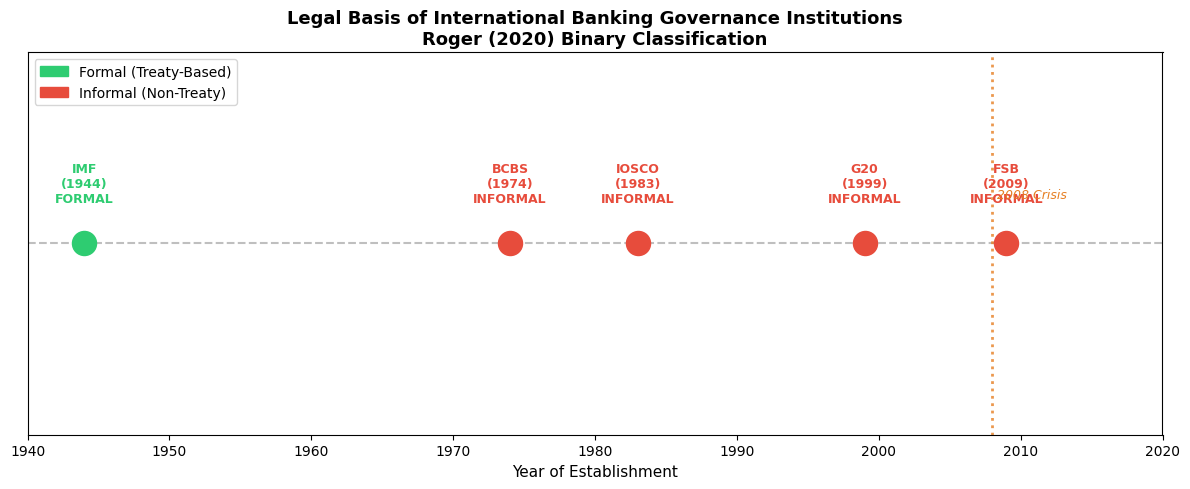

Figure saved to: ../outputs/figures/indicator1_formal_informal_timeline.png


In [6]:
# Timeline visualization — formal vs. informal classification across institutions

fig, ax = plt.subplots(figsize=(12, 5))

# Color coding
colors = {"FORMAL": "#2ecc71", "INFORMAL": "#e74c3c"}

# Plot each institution as a point on the timeline
for _, row in df.iterrows():
    color = colors[row["classification"]]
    ax.scatter(row["founded"], 0.5, color=color, s=300, zorder=5)
    ax.annotate(
        f"{row['acronym']}\n({row['founded']})\n{row['classification']}",
        xy=(row["founded"], 0.5),
        xytext=(0, 30),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=color
    )

# Timeline line
ax.axhline(y=0.5, color="grey", linewidth=1.5, linestyle="--", alpha=0.5)

# Mark 2008 crisis
ax.axvline(x=2008, color="#e67e22", linewidth=2, linestyle=":", alpha=0.8)
ax.text(2008.3, 0.62, "2008 Crisis", fontsize=9, color="#e67e22", fontstyle="italic")

# Formatting
ax.set_xlim(1940, 2020)
ax.set_ylim(0, 1)
ax.set_xlabel("Year of Establishment", fontsize=11)
ax.set_title(
    "Legal Basis of International Banking Governance Institutions\nRoger (2020) Binary Classification",
    fontsize=13, fontweight="bold"
)
ax.set_yticks([])

# Legend
formal_patch = mpatches.Patch(color="#2ecc71", label="Formal (Treaty-Based)")
informal_patch = mpatches.Patch(color="#e74c3c", label="Informal (Non-Treaty)")
ax.legend(handles=[formal_patch, informal_patch], loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/indicator1_formal_informal_timeline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to: ../outputs/figures/indicator1_formal_informal_timeline.png")

### Figure 1 — Legal Basis of International Banking Governance Institutions

The timeline makes the informalization pattern immediately visible. Every institution 
created after the IMF in 1944 — the BCBS (1974), IOSCO (1983), G20 (1999), and FSB 
(2009) — is informal. More importantly, the 2008 crisis marker reveals the critical 
finding: **the most ambitious post-crisis institutional response in financial governance 
history produced zero new formal institutions**. The FSB, established in 2009 as the 
centrepiece of the G20's reform agenda, sits on the wrong side of the line — informal, 
non-treaty, non-binding.

This directly corroborates Roger's (2020) domestic politics theory: independent 
regulatory agencies, which drove the post-2008 response, systematically prefer informal 
arrangements that preserve operational autonomy. The pattern is not random — it is 
structurally produced.

This finding establishes the baseline for Indicator 2: if the institutions are informal, 
the next question is how informal their outputs are — and whether that informality has 
deepened or merely persisted across the Basel sequence.